# Task 2: Predict Future Stock Prices (Short-Term)

**Objective:** Use historical stock data to predict the next day's closing price.

**Dataset:** Apple (AAPL) stock data fetched via the `yfinance` library

**Skills Covered:** time series data, yfinance API, Linear Regression, Random Forest, visualization


## Step 1: Install & Import Libraries

In [3]:
# yfinance is not always pre-installed, so we install it
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "yfinance", "--quiet"], check=False)


CompletedProcess(args=['c:\\Users\\user\\AppData\\Local\\Programs\\Python\\Python310\\python.exe', '-m', 'pip', 'install', 'yfinance', '--quiet'], returncode=0)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
print("All libraries ready.")


All libraries ready.


## Step 2: Fetch Historical Stock Data

In [5]:
# pulling 2 years of Apple stock data — a decent window for short-term prediction
ticker = "AAPL"
data = yf.download(ticker, start="2022-01-01", end="2024-01-01", progress=False)

print(f"Downloaded {len(data)} trading days of {ticker} data.")
print(f"Columns: {data.columns.tolist()}")
data.head()


Downloaded 501 trading days of AAPL data.
Columns: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939758,178.790313,173.735930,173.853242,104487900
2022-01-04,175.681412,178.848962,175.114380,178.545897,99310400
2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000
2022-01-07,168.319763,170.245709,167.205258,169.023663,86709100


In [6]:
# quick sanity check — any missing values?
print("Missing values per column:")
print(data.isnull().sum())


Missing values per column:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


## Step 3: Feature Engineering

In [7]:
# we'll use Open, High, Low, Volume to predict next day's Close
# the trick is to shift the Close column by -1 so each row's target
# is the NEXT day's closing price, not the current one
df = data[["Open", "High", "Low", "Close", "Volume"]].copy()

# flatten MultiIndex columns if present (yfinance sometimes returns these)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df["Target"] = df["Close"].shift(-1)   # next day's close = what we want to predict

# drop the last row because it has no "next day" target
df.dropna(inplace=True)

print(f"Feature matrix shape: {df.shape}")
df.head()


Feature matrix shape: (500, 6)


Price,Open,High,Low,Close,Volume,Target
Date,,,,,,
2022-01-03,173.853242,178.790313,173.735930,177.939758,104487900,175.681412
2022-01-04,178.545897,178.848962,175.114380,175.681412,99310400,171.008270
2022-01-05,175.593390,176.140865,170.734533,171.008270,94537600,168.153595
2022-01-06,168.837938,171.379801,167.801645,168.153595,96904000,168.319763
2022-01-07,169.023663,170.245709,167.205258,168.319763,86709100,168.339310


In [8]:
# let's also add a few simple technical indicators to give the model more signal
df["MA_5"]  = df["Close"].rolling(5).mean()    # 5-day moving average
df["MA_20"] = df["Close"].rolling(20).mean()   # 20-day moving average
df["Daily_Return"] = df["Close"].pct_change()  # day-over-day % change

# drop rows where rolling windows produced NaN
df.dropna(inplace=True)
print(f"Shape after adding indicators: {df.shape}")


Shape after adding indicators: (481, 9)


## Step 4: Prepare Features and Labels

In [9]:
feature_cols = ["Open", "High", "Low", "Close", "Volume", "MA_5", "MA_20", "Daily_Return"]

X = df[feature_cols]
y = df["Target"]

# 80/20 split — keep the split sequential (no shuffle) since this is time series data
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")


Training samples: 384
Test samples:     97


In [10]:
# scale features — helps Linear Regression converge better
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


## Step 5: Train Models

In [11]:
# --- Linear Regression ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

print("Both models trained.")


Both models trained.


## Step 6: Evaluate Models

In [12]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name}:")
    print(f"  MAE  = ${mae:.2f}")
    print(f"  RMSE = ${rmse:.2f}")
    print(f"  R²   = {r2:.4f}")
    print()

evaluate("Linear Regression", y_test, lr_preds)
evaluate("Random Forest",     y_test, rf_preds)


Linear Regression:
  MAE  = $1.74
  RMSE = $2.19
  R²   = 0.9325

Random Forest:
  MAE  = $1.95
  RMSE = $2.56
  R²   = 0.9077



## Step 7: Visualize Predictions vs Actual

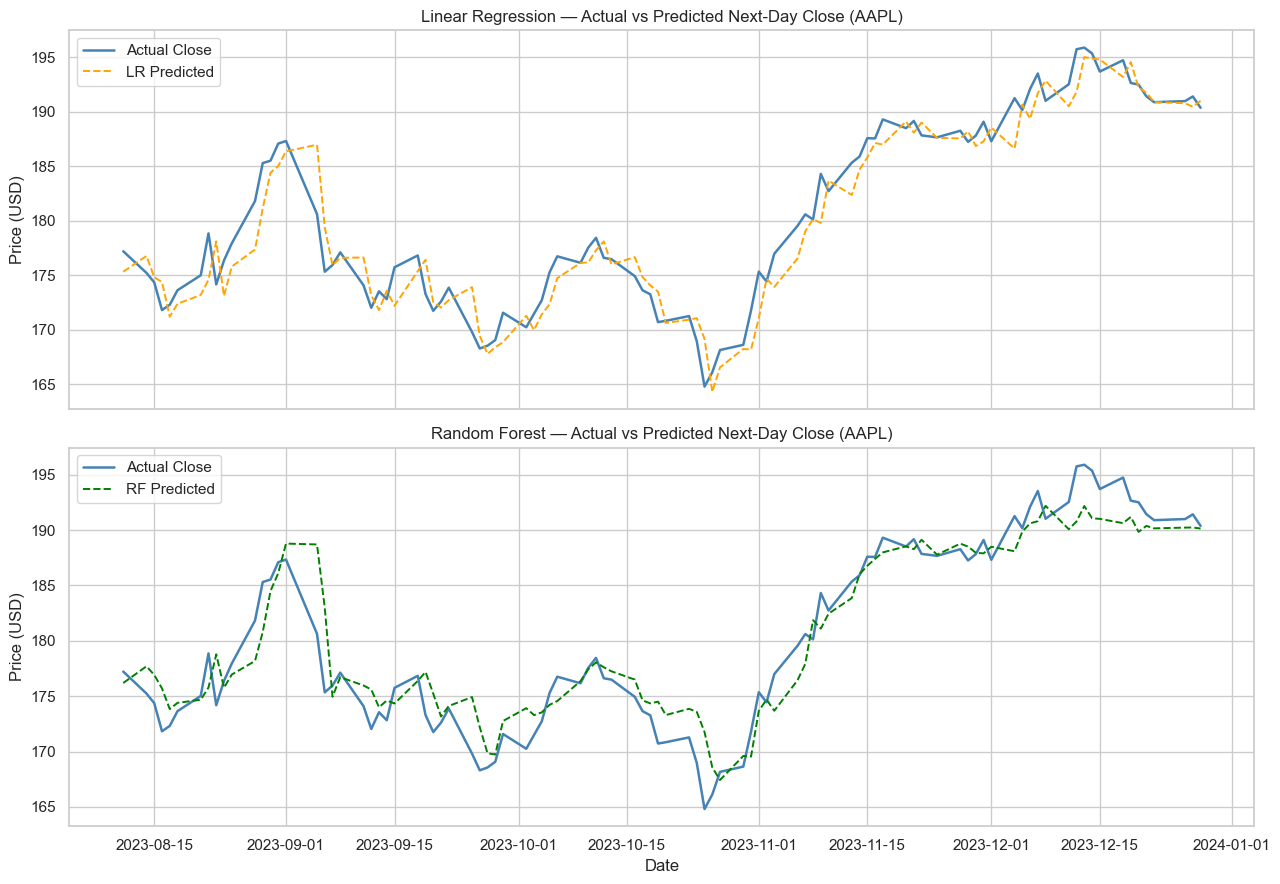

In [13]:
test_dates = df.index[split:]

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Linear Regression plot
axes[0].plot(test_dates, y_test.values, label="Actual Close", color="steelblue", linewidth=1.8)
axes[0].plot(test_dates, lr_preds, label="LR Predicted", color="orange", linestyle="--", linewidth=1.4)
axes[0].set_title("Linear Regression — Actual vs Predicted Next-Day Close (AAPL)")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()

# Random Forest plot
axes[1].plot(test_dates, y_test.values, label="Actual Close", color="steelblue", linewidth=1.8)
axes[1].plot(test_dates, rf_preds, label="RF Predicted", color="green", linestyle="--", linewidth=1.4)
axes[1].set_title("Random Forest — Actual vs Predicted Next-Day Close (AAPL)")
axes[1].set_ylabel("Price (USD)")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()


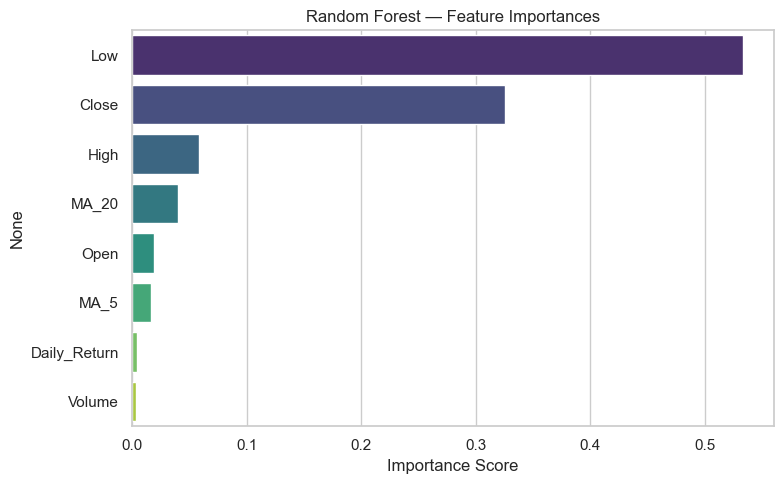

In [14]:
# feature importance from Random Forest — which inputs mattered most?
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Random Forest — Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


## Summary

- We fetched **2 years** of Apple (AAPL) daily stock data using `yfinance`.
- Features used: Open, High, Low, Close, Volume + 3 engineered indicators (MA5, MA20, Daily Return).
- **Random Forest** outperformed Linear Regression on both MAE and R².
- The `Close` price of the current day is the most important predictor of tomorrow's close (makes intuitive sense).
- Short-term stock prediction is inherently noisy — even a good R² doesn't mean perfect trades!
